# Benchmark — Frequencia_Cor · Luminescência · Ruído
Avalia os três modelos treinados em um conjunto de imagens e calcula acurácia, F1, AUC-ROC, tempo médio e matriz de confusão. Inclui ensemble por média das probabilidades calibradas.

In [6]:
import io
import json
import time
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.ndimage import convolve
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_auc_score,
)

# ── Configuração ──────────────────────────────────────────────────────────────
REAL_DIR   = Path(r'D:\TCCDataset\test\real')
IA_DIR     = Path(r'D:\TCCDataset\test\fake')
LIMIT      = 300   # imagens por classe; None = todas
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tiff', '.jfif'}

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / '.git').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FC_MODEL       = PROJECT_ROOT / 'modelos/Frequencia_Cor/modelo_freq_cor_v1.pkl'
FC_SCALER      = PROJECT_ROOT / 'modelos/Frequencia_Cor/scaler_freq_cor.pkl'
FC_CALIBRATOR  = PROJECT_ROOT / 'modelos/Frequencia_Cor/calibrator_freq_cor.pkl'
FC_THRESHOLD   = PROJECT_ROOT / 'modelos/Frequencia_Cor/threshold.json'

LUM_MODEL      = PROJECT_ROOT / 'modelos/Luminescencia/svm_luminance.pkl'
LUM_SCALER     = PROJECT_ROOT / 'modelos/Luminescencia/scaler_luminance.pkl'
LUM_CALIBRATOR = PROJECT_ROOT / 'modelos/Luminescencia/calibrator_luminance.pkl'
LUM_THRESHOLD  = PROJECT_ROOT / 'modelos/Luminescencia/threshold.json'

RUIDO_MODEL     = PROJECT_ROOT / 'modelos/Ruido/modelo_ruido.pkl'
RUIDO_THRESHOLD = PROJECT_ROOT / 'modelos/Ruido/threshold.json'

print('Projeto:', PROJECT_ROOT)

Projeto: c:\Users\user\Desktop\TCC\Xiz9


In [7]:
# ── Extração de features — Frequencia_Cor ─────────────────────────────────────

def _pca_distribution_features(eig):
    eig_sorted = np.sort(eig)[::-1]
    norm_eig   = eig_sorted / (eig_sorted.sum() + 1e-12)
    eigen_entropy = float(-np.sum(norm_eig * np.log(norm_eig + 1e-12)))
    top5_ratio    = float(eig_sorted[:5].sum() / (eig_sorted[-5:].sum() + 1e-12))
    cumsum = np.cumsum(norm_eig)
    n_50   = int(np.searchsorted(cumsum, 0.50) + 1)
    n_90   = int(np.searchsorted(cumsum, 0.90) + 1)
    n_95   = int(np.searchsorted(cumsum, 0.95) + 1)
    k      = np.arange(1, len(eig_sorted) + 1)
    slope  = float(np.polyfit(np.log(k), np.log(eig_sorted + 1e-12), 1)[0])
    return [eigen_entropy, top5_ratio, n_50, n_90, n_95, slope]


def freq_cor_features(image_bytes):
    N_PCA_COMP = 30
    RESIZE_TO  = (256, 256)

    img_rgb  = Image.open(io.BytesIO(image_bytes)).convert('RGB').resize(RESIZE_TO)
    img_gray = img_rgb.convert('L')
    arr_rgb  = np.array(img_rgb,  dtype=np.float64) / 255.0
    arr_gray = np.array(img_gray, dtype=np.float64) / 255.0

    n      = min(N_PCA_COMP, min(arr_gray.shape))
    pca    = PCA(n_components=n, svd_solver='randomized', random_state=42)
    scores = pca.fit_transform(arr_gray)
    eig    = pca.explained_variance_
    evr    = pca.explained_variance_ratio_

    pca_inv_feats = _pca_distribution_features(eig)

    geo_mean  = float(np.exp(np.mean(np.log(eig + 1e-12))))
    spec_flat = geo_mean / (float(np.mean(eig)) + 1e-12)
    first_dom = float(evr[0])
    coef_var  = float(np.std(eig) / (np.mean(eig) + 1e-12))

    def _rec(k):
        sk = np.zeros_like(scores); sk[:, :k] = scores[:, :k]
        return float(np.mean((arr_gray - pca.inverse_transform(sk)) ** 2))

    pca_scalar_feats = [spec_flat, first_dom, coef_var,
                        _rec(min(5, n)), _rec(min(10, n)), _rec(min(20, n))]

    color_feats = []
    for c in range(3):
        ch = arr_rgb[:, :, c].ravel()
        mu = ch.mean(); sd = ch.std() + 1e-12
        color_feats += [float(mu), float(sd),
                        float(np.mean(((ch - mu) / sd) ** 3)),
                        float(np.mean(((ch - mu) / sd) ** 4))]

    try:
        arr_hsv = np.array(img_rgb.convert('HSV'), dtype=np.float64) / 255.0
        hsv_feats = []
        for c in range(3):
            ch = arr_hsv[:, :, c].ravel()
            hsv_feats += [float(np.mean(ch)), float(np.std(ch))]
    except Exception:
        hsv_feats = [0.0] * 6

    fft     = np.fft.fft2(arr_gray)
    fft_mag = np.abs(np.fft.fftshift(fft))
    h, w    = fft_mag.shape; cy, cx = h // 2, w // 2
    Y, X    = np.ogrid[:h, :w]
    dist    = np.sqrt((X - cx)**2 + (Y - cy)**2)
    md      = np.sqrt(cx**2 + cy**2)
    e_low   = float(np.sum(fft_mag[dist <= md * 0.1]**2))
    e_mid   = float(np.sum(fft_mag[(dist > md * 0.1) & (dist <= md * 0.4)]**2))
    e_high  = float(np.sum(fft_mag[dist > md * 0.4]**2))
    e_tot   = e_low + e_mid + e_high + 1e-12
    fft_feats = [e_low/e_tot, e_mid/e_tot, e_high/e_tot,
                 e_high/(e_low + 1e-12), float(np.std(np.log1p(fft_mag)))]

    result = np.array(pca_inv_feats + pca_scalar_feats + color_feats + hsv_feats + fft_feats,
                      dtype=np.float32)
    return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

In [8]:
# ── Extração de features — Luminescência ──────────────────────────────────────

def lum_features(image_bytes):
    from scipy.ndimage import sobel as scipy_sobel
    RESIZE_TO = (256, 256)
    GRID      = 4
    N_COMP    = 30

    img_array = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        return None

    img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float64)
    img_r      = cv2.resize(img_rgb, RESIZE_TO)
    luminancia = 0.299*img_r[:,:,0] + 0.587*img_r[:,:,1] + 0.114*img_r[:,:,2]

    grad_x    = scipy_sobel(luminancia, axis=1)
    grad_y    = scipy_sobel(luminancia, axis=0)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    direcao   = np.arctan2(grad_y, grad_x)

    n   = min(N_COMP, min(magnitude.shape))
    pca = PCA(n_components=n, svd_solver='randomized', random_state=42)
    pca.fit(magnitude)
    eig = pca.explained_variance_

    pca_feats = _pca_distribution_features(eig) + [
        float(np.std(direcao)),
        float(np.mean(magnitude)),
        float(np.std(magnitude)),
        float(np.percentile(magnitude, 90)),
        float(np.mean(magnitude) / (np.std(magnitude) + 1e-10)),
    ]

    fft_mag   = np.abs(np.fft.fftshift(np.fft.fft2(magnitude)))
    h, w      = fft_mag.shape; cy, cx = h//2, w//2
    Y, X      = np.ogrid[:h, :w]
    dist      = np.sqrt((X-cx)**2 + (Y-cy)**2)
    md        = np.sqrt(cx**2 + cy**2)
    e_low     = float(np.sum(fft_mag[dist <= md*0.1]**2))
    e_mid     = float(np.sum(fft_mag[(dist > md*0.1) & (dist <= md*0.4)]**2))
    e_high    = float(np.sum(fft_mag[dist > md*0.4]**2))
    e_tot     = e_low + e_mid + e_high + 1e-12
    fft_feats = [e_low/e_tot, e_mid/e_tot, e_high/e_tot,
                 e_high/(e_low + 1e-12), float(np.std(np.log1p(fft_mag)))]

    hist_dir, _ = np.histogram(direcao, bins=8, range=(-np.pi, np.pi))
    hist_dir    = hist_dir / (hist_dir.sum() + 1e-10)
    hog_feats   = hist_dir.tolist()

    coer_v = float(np.mean(np.cos(direcao[:-1,:] - direcao[1:,:])))
    coer_h = float(np.mean(np.cos(direcao[:,:-1] - direcao[:,1:])))

    blur       = cv2.GaussianBlur(magnitude.astype(np.float32), (15, 15), 0)
    mag_norm   = magnitude / (blur.astype(np.float64) + 1e-6)
    norm_feats = [float(np.mean(mag_norm)), float(np.std(mag_norm)),
                  float(np.percentile(mag_norm, 95))]

    bh, bw      = RESIZE_TO[0]//GRID, RESIZE_TO[1]//GRID
    block_feats = []
    for i in range(GRID):
        for j in range(GRID):
            bloco = magnitude[i*bh:(i+1)*bh, j*bw:(j+1)*bw]
            block_feats += [float(np.mean(bloco)), float(np.std(bloco)),
                            float(np.percentile(bloco, 90))]

    all_feats = pca_feats + fft_feats + hog_feats + [coer_v, coer_h] + norm_feats + block_feats
    result    = np.array(all_feats, dtype=np.float64)
    return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0).tolist()

In [9]:
# ── Extração de features — Ruído ──────────────────────────────────────────────

_SRM_FILTERS = [
    np.array([[0,0,0],[0,-1,1],[0,0,0]],   dtype=np.float32),
    np.array([[0,0,0],[0,-1,0],[0,1,0]],   dtype=np.float32),
    np.array([[0,0,0],[0,-2,1],[0,1,0]],   dtype=np.float32),
    np.array([[-1,2,-1],[0,0,0],[0,0,0]], dtype=np.float32),
    np.array([[0,0,0],[-1,2,-1],[0,0,0]], dtype=np.float32),
    np.array([[-1,0,0],[2,0,0],[-1,0,0]], dtype=np.float32),
    np.array([[0,-1,0],[0,2,0],[0,-1,0]], dtype=np.float32),
    np.array([[-1,0,1],[0,0,0],[1,0,-1]], dtype=np.float32),
    np.array([[1,-2,1],[-2,4,-2],[1,-2,1]], dtype=np.float32),
]

def ruido_features(image_bytes):
    PATCH_SIZE = 32
    N_PATCHES  = 3
    img = Image.open(io.BytesIO(image_bytes)).convert('L').resize((256, 256))
    arr = np.array(img, dtype=np.float32) / 255.0
    h, w = arr.shape

    patches = []
    for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
            patch = arr[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            patches.append((float(np.sum(np.abs(cv2.dct(patch)))), patch))
    if not patches:
        return None
    patches.sort(key=lambda p: p[0])
    selected = [p for _, p in patches[:N_PATCHES]] + [p for _, p in patches[-N_PATCHES:]]

    features = []
    for patch in selected:
        for f in _SRM_FILTERS:
            filtered = convolve(patch, f)
            features.extend([float(np.mean(np.abs(filtered))), float(np.std(filtered))])

    laplacian = cv2.Laplacian((arr * 255).astype(np.uint8), cv2.CV_64F)
    features.extend([
        float(np.var(laplacian)),
        float(np.mean(np.abs(laplacian))),
        float(np.std(laplacian)),
        float(np.percentile(np.abs(laplacian), 90)),
    ])
    return np.array(features)

In [10]:
# ── Carga de imagens ──────────────────────────────────────────────────────────

def load_images(real_dir, ia_dir, limit=None):
    real = sorted([p for p in real_dir.iterdir() if p.suffix.lower() in EXTENSIONS])
    ia   = sorted([p for p in ia_dir.iterdir()   if p.suffix.lower() in EXTENSIONS])
    if limit:
        real = real[:limit]; ia = ia[:limit]
    samples = [(p, 0) for p in real] + [(p, 1) for p in ia]
    print(f'Dataset: {len(samples)} imagens  ({len(real)} reais, {len(ia)} IA)')
    return samples

samples = load_images(REAL_DIR, IA_DIR, limit=LIMIT)

Dataset: 600 imagens  (300 reais, 300 IA)


In [11]:
# ── Função de benchmark ───────────────────────────────────────────────────────

def run_model(samples, extract_fn, model, scaler=None, calibrator=None,
              threshold=0.5, name='Modelo'):
    y_true, y_pred, y_proba = [], [], []
    times, erros = [], 0
    n = len(samples)

    for i, (path, label) in enumerate(samples):
        if i % 50 == 0:
            print(f'  {name}: {i}/{n}', end='\r')
        try:
            img_bytes = path.read_bytes()
            t0   = time.perf_counter()
            feat = extract_fn(img_bytes)
            if feat is None:
                erros += 1; continue
            feat_s  = scaler.transform([feat]) if scaler is not None else [feat]
            raw_p   = model.predict_proba(feat_s)[0, 1]
            prob_ia = float(calibrator.predict([raw_p])[0]) if calibrator is not None else float(raw_p)
            pred    = int(prob_ia >= threshold)
            times.append(time.perf_counter() - t0)
            y_true.append(label); y_pred.append(pred); y_proba.append(prob_ia)
        except Exception as e:
            erros += 1

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_proba = np.array(y_proba)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    cm  = confusion_matrix(y_true, y_pred)

    print(f'\n{"─"*55}')
    print(f'  {name}')
    print(f'{"─"*55}')
    print(f'  Imagens    : {len(y_true)}  ({erros} com erro)')
    print(f'  Acurácia   : {acc:.4f}   F1: {f1:.4f}   AUC: {auc:.4f}')
    print(f'  Threshold  : {threshold:.4f}')
    print(f'  Tempo médio: {np.mean(times)*1000:.1f} ms/img')
    print(classification_report(y_true, y_pred, target_names=['REAL','IA'], digits=4))

    return dict(name=name, acc=acc, f1=f1, auc=auc, cm=cm,
                y_true=y_true, y_pred=y_pred, y_proba=y_proba, times=times)

In [12]:
# ── Frequencia_Cor ────────────────────────────────────────────────────────────

fc_model      = joblib.load(FC_MODEL)
fc_scaler     = joblib.load(FC_SCALER)
fc_calibrator = joblib.load(FC_CALIBRATOR)
with open(FC_THRESHOLD) as f:
    fc_thr = json.load(f)['threshold']

res_fc = run_model(samples, freq_cor_features, fc_model, fc_scaler, fc_calibrator,
                   fc_thr, 'Frequencia_Cor')

  Frequencia_Cor: 550/600
───────────────────────────────────────────────────────
  Frequencia_Cor
───────────────────────────────────────────────────────
  Imagens    : 600  (0 com erro)
  Acurácia   : 0.7183   F1: 0.7547   AUC: 0.8312
  Threshold  : 0.4351
  Tempo médio: 183.5 ms/img
              precision    recall  f1-score   support

        REAL     0.8104    0.5700    0.6693       300
          IA     0.6684    0.8667    0.7547       300

    accuracy                         0.7183       600
   macro avg     0.7394    0.7183    0.7120       600
weighted avg     0.7394    0.7183    0.7120       600



In [13]:
# ── Luminescência ─────────────────────────────────────────────────────────────

lum_model      = joblib.load(LUM_MODEL)
lum_scaler     = joblib.load(LUM_SCALER)
lum_calibrator = joblib.load(LUM_CALIBRATOR)
with open(LUM_THRESHOLD) as f:
    lum_thr = json.load(f)['threshold']

res_lum = run_model(samples, lum_features, lum_model, lum_scaler, lum_calibrator,
                    lum_thr, 'Luminescencia')

  Luminescencia: 550/600
───────────────────────────────────────────────────────
  Luminescencia
───────────────────────────────────────────────────────
  Imagens    : 600  (0 com erro)
  Acurácia   : 0.8700   F1: 0.8687   AUC: 0.9291
  Threshold  : 0.5000
  Tempo médio: 175.3 ms/img
              precision    recall  f1-score   support

        REAL     0.8627    0.8800    0.8713       300
          IA     0.8776    0.8600    0.8687       300

    accuracy                         0.8700       600
   macro avg     0.8701    0.8700    0.8700       600
weighted avg     0.8701    0.8700    0.8700       600



In [14]:
# ── Ruído ─────────────────────────────────────────────────────────────────────

ruido_model = joblib.load(RUIDO_MODEL)
with open(RUIDO_THRESHOLD) as f:
    ruido_thr = json.load(f)['threshold']

res_ruido = run_model(samples, ruido_features, ruido_model, None, None,
                      ruido_thr, 'Ruido')

  Ruido: 550/600
───────────────────────────────────────────────────────
  Ruido
───────────────────────────────────────────────────────
  Imagens    : 600  (0 com erro)
  Acurácia   : 0.8033   F1: 0.8127   AUC: 0.8635
  Threshold  : 0.3808
  Tempo médio: 77.9 ms/img
              precision    recall  f1-score   support

        REAL     0.8370    0.7533    0.7930       300
          IA     0.7758    0.8533    0.8127       300

    accuracy                         0.8033       600
   macro avg     0.8064    0.8033    0.8028       600
weighted avg     0.8064    0.8033    0.8028       600



In [15]:
# ── Ensemble — média das probabilidades calibradas ────────────────────────────

def run_ensemble(results_list):
    # alinha pelo menor conjunto sem erro
    min_len = min(len(r['y_true']) for r in results_list)
    y_true  = results_list[0]['y_true'][:min_len]

    stacked    = np.stack([r['y_proba'][:min_len] for r in results_list], axis=1)
    mean_proba = stacked.mean(axis=1)
    y_pred_ens = (mean_proba >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred_ens)
    f1  = f1_score(y_true, y_pred_ens)
    auc = roc_auc_score(y_true, mean_proba)
    cm  = confusion_matrix(y_true, y_pred_ens)

    print(f'\n{"─"*55}')
    print(f'  Ensemble (média das probabilidades calibradas)')
    print(f'{"─"*55}')
    print(f'  Acurácia: {acc:.4f}   F1: {f1:.4f}   AUC: {auc:.4f}')
    print(classification_report(y_true, y_pred_ens, target_names=['REAL','IA'], digits=4))

    return dict(name='Ensemble', acc=acc, f1=f1, auc=auc, cm=cm,
                y_true=y_true, y_pred=y_pred_ens, y_proba=mean_proba)

res_ens = run_ensemble([res_fc, res_lum, res_ruido])


───────────────────────────────────────────────────────
  Ensemble (média das probabilidades calibradas)
───────────────────────────────────────────────────────
  Acurácia: 0.8650   F1: 0.8634   AUC: 0.9375
              precision    recall  f1-score   support

        REAL     0.8567    0.8767    0.8666       300
          IA     0.8737    0.8533    0.8634       300

    accuracy                         0.8650       600
   macro avg     0.8652    0.8650    0.8650       600
weighted avg     0.8652    0.8650    0.8650       600



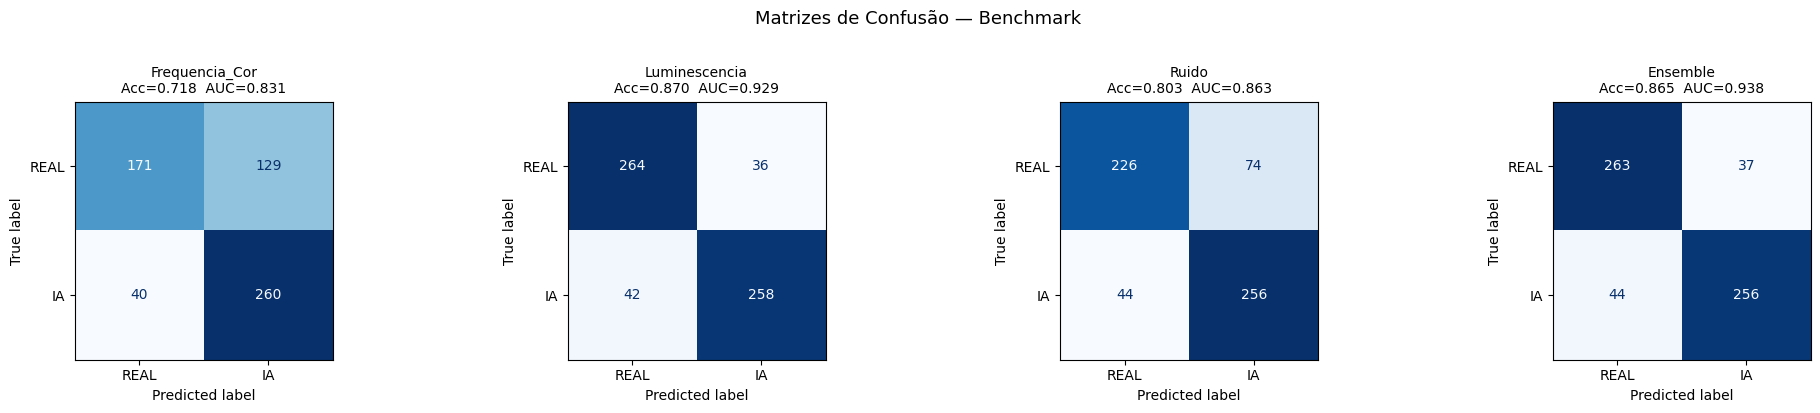

In [16]:
# ── Matrizes de confusão ──────────────────────────────────────────────────────

resultados = [res_fc, res_lum, res_ruido, res_ens]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, res in zip(axes, resultados):
    ConfusionMatrixDisplay(res['cm'], display_labels=['REAL', 'IA']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"{res['name']}\nAcc={res['acc']:.3f}  AUC={res['auc']:.3f}",
                 fontsize=10)
plt.suptitle('Matrizes de Confusão — Benchmark', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ── Tabela resumo ─────────────────────────────────────────────────────────────

rows = []
for r in resultados:
    avg_ms = np.mean(r['times']) * 1000 if r.get('times') else float('nan')
    rows.append({
        'Modelo':        r['name'],
        'Acurácia':      round(r['acc'], 4),
        'F1':            round(r['f1'],  4),
        'AUC-ROC':       round(r['auc'], 4),
        'Tempo médio (ms)': round(avg_ms, 1),
    })

df = pd.DataFrame(rows).set_index('Modelo')
df

,Acurácia,F1,AUC-ROC,Tempo médio (ms)
Modelo,,,,
Frequencia_Cor,0.7183,0.7547,0.8312,183.5
Luminescencia,0.8700,0.8687,0.9291,175.3
Ruido,0.8033,0.8127,0.8635,77.9
Ensemble,0.8650,0.8634,0.9375,NaN


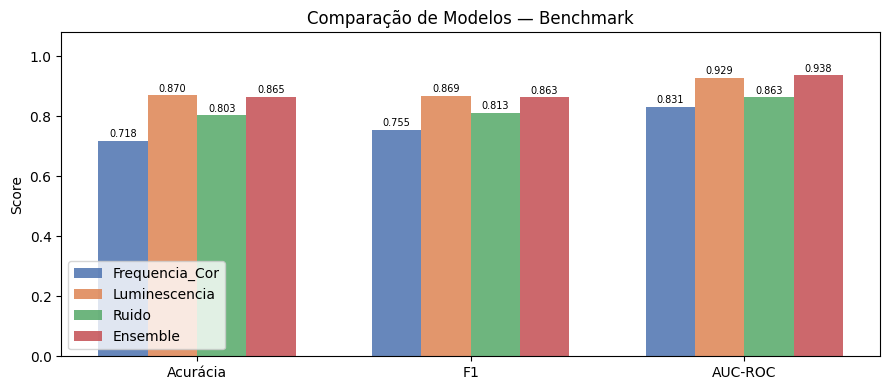

In [18]:
# ── Gráfico de barras comparativo ─────────────────────────────────────────────

metricas = ['Acurácia', 'F1', 'AUC-ROC']
x = np.arange(len(metricas))
width = 0.18
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 4))
for i, (res, col) in enumerate(zip(resultados, colors)):
    vals = [res['acc'], res['f1'], res['auc']]
    bars = ax.bar(x + i*width, vals, width, label=res['name'], color=col, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Benchmark')
ax.legend()
plt.tight_layout()
plt.show()